# Molecular Solubility Prediction using PyCaret

## Overview
This notebook demonstrates the application of low-code machine learning workflows using PyCaret for molecular solubility prediction.

The project focuses on:
- Data preprocessing
- Automated regression model comparison
- Model evaluation
- Predictive performance analysis

PyCaret was utilized to simplify machine learning experimentation and accelerate model development for cheminformatics applications.

## Objectives
The objective is to evaluate multiple regression algorithms and identify models capable of accurately predicting molecular solubility (`LogS`) from molecular descriptor features.

## Tools and Libraries
- Python
- PyCaret
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- RDKit

## Acknowledgment
Initial workflow inspired by educational resources from Data Professor and cheminformatics research literature.

## **1. Install conda and libraries**

In [ ]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

--2026-05-11 12:53:33--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’

Miniconda3-py37_4.8 100%[===================>]  81.12M   200MB/s    in 0.4s    

2026-05-11 12:53:34 (200 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: | / done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - asn1crypto==1.3.0=py37_0
    - ca-certificates==2020.1.1=0
    - certifi==2019.11.28=py37_0
    - cffi==1.14.0=py37h2e261b9_0
    - chardet==3.0.4=py37_1003
    - conda-package-handling==1.6.0=p

## Load Solubility Dataset

The Delaney solubility dataset was used for regression modeling and predictive analysis of molecular aqueous solubility (`LogS`).

### Dataset Acquisition

In [ ]:
# ! wget https://pubs.acs.org/doi/suppl/10.1021/ci034243x/suppl_file/ci034243xsi20040112_053635.txt

### Load Dataset into Pandas

In [ ]:
import pandas as pd

In [ ]:
delaney_url = 'https://raw.githubusercontent.com/dataprofessor/data/master/delaney.csv'
sol = pd.read_csv(delaney_url)
sol

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.180,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.000,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.740,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.480,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.040,-3.077,FC(F)(Cl)C(F)(Cl)Cl
...,...,...,...,...
1139,vamidothion,1.144,-1.446,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
1140,Vinclozolin,-4.925,-4.377,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C
1141,Warfarin,-3.893,-3.913,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O
1142,Xipamide,-3.790,-3.642,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O


## Molecular Descriptor Calculation using RDKit

### Conversion of Molecules to RDKit Objects

In [ ]:
!pip install rdkit

     |████████████████████████████████| 29.5 MB 240 kB/s 


In [ ]:
import sys
print(sys.executable)  # Run this first to see your kernel's Python path

/usr/bin/python3


In [ ]:
import sys
!{sys.executable} -m pip install rdkit

In [ ]:
from rdkit import Chem
print(Chem.MolFromSmiles('CCO'))

In [ ]:
from rdkit import Chem

In [ ]:
mol_list = [Chem.MolFromSmiles(element) for element in sol.SMILES]

In [ ]:
len(mol_list)

1144

In [ ]:
mol_list[:5]

### Molecular Descriptor Computation

To predict aqueous solubility (`LogS`), several physicochemical molecular descriptors were calculated using RDKit.

The descriptors include:
1. LogP (octanol-water partition coefficient)
2. Molecular Weight (MW)
3. Number of Rotatable Bonds (RB)
4. Aromatic Proportion (AP)

These descriptors provide quantitative information about molecular structure and physicochemical properties relevant to solubility prediction.

In [ ]:
import numpy as np
from rdkit.Chem import Descriptors

In [ ]:
def AromaticProportion(m):
  aromatic_atoms = [m.GetAtomWithIdx(i).GetIsAromatic() for i in range(m.GetNumAtoms())]
  aa_count = []
  for i in aromatic_atoms:
    if i==True:
      aa_count.append(1)
  AromaticAtom = sum(aa_count)
  HeavyAtom = Descriptors.HeavyAtomCount(m)
  AR = AromaticAtom/HeavyAtom
  return AR

In [ ]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def generate(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_MolWt = Descriptors.MolWt(mol)
        desc_NumRotatableBonds = Descriptors.NumRotatableBonds(mol)
        desc_AromaticProportion = AromaticProportion(mol)

        row = np.array([desc_MolLogP,
                        desc_MolWt,
                        desc_NumRotatableBonds,
                        desc_AromaticProportion])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MolLogP","MolWt","NumRotatableBonds","AromaticProportion"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [ ]:
X = generate(sol.SMILES)

# Preparation of Feature and Target Matrices

## Feature Matrix (X)

In [ ]:
X

## Target Vector (Y)

The target variable (`Y`) was assigned using the solubility values from the dataset.

In [ ]:
Y = sol.iloc[:,1]
Y = Y.rename("logS")
Y

,logS
0,-2.180
1,-2.000
2,-1.740
3,-1.480
4,-3.040
...,...
1139,1.144
1140,-4.925
1141,-3.893
1142,-3.790


In [ ]:
Y

,logS
0,-2.180
1,-2.000
2,-1.740
3,-1.480
4,-3.040
...,...
1139,1.144
1140,-4.925
1141,-3.893
1142,-3.790


<Axes: >

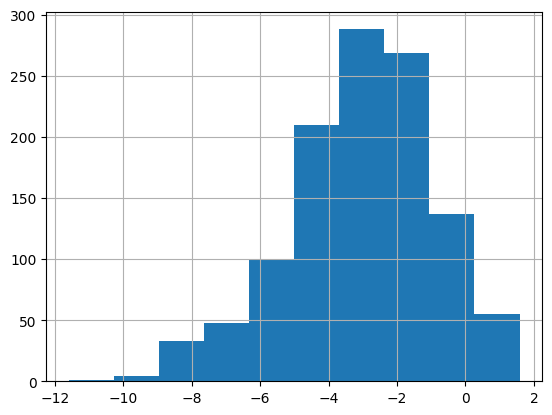

In [ ]:
Y.hist()

## Construction of the Final Modeling Dataset

In [ ]:
dataset = pd.concat([X,Y], axis=1)
dataset

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


In [ ]:
dataset.to_csv('solubility_descriptor_dataset.csv', index=False)

---